# Práctica 5: Modelo Browniano Geométrico

Considera un modelo de precios browniano geométrico con $S_{0}=100$, $\mu=10\%$ anual, $\sigma=20\%$ anual, $r=5\%$ con composición continua, $\tau=T/N$, donde $T=1$ año y un número creciente de intervalos $N=10^{j}$, para valores de $j=1,2,3$.

## Tareas

a) Realiza $1000$ simulaciones del modelo bajo la medida neutral al riesgo. Repite el mismo número de simulaciones para el proceso equivalente $W$. Compara los histogramas de ambas muestras para los distintos valores de $j$ dados.

b) Utilizando el árbol binomial recombinante basado en la variable $\tilde{X}$ y la medida neutral al riesgo $q$ calcula el precio de una opción de compra $C$ y de la opción de venta $P$ con valor strike $K=110$ (el mismo para las dos). Cambia el valor de la deriva $\mu$ al $20\%$ recalcula la media y los precios, ¿qué se observa?

c) Calcula los precios pedidos en b) pero ahora utilizando un árbol basado en la variable $W$, es decir, aplicando el cambio de medida explicado en la teoría.

**Respuesta**: Precio Call $6.0400$ euros, precio Put $10.6753$ euros para $N=1000$.

**Resolución del apartado a)**  
Los apartados b) y c) pueden hacerse utilizando las herramientas que presentamos aquí para generar los valores finales de $S$ y el algoritmo de valoración del modelo de Cox Ross Rubinstein ya visto.

In [ ]:
import numpy as np
# definimos los parámetros
S0 = 100
sigma = 0.2
r = 0.05
mu = 0.10
T = 1
N = 1000 #
tau = T/N # tamaño del paso temporal
sqrtau = np.sqrt(tau) # raíz de tau
v = sigma*sqrtau
q = 1/2 - sqrtau*(mu-r)/(2*sigma)# la probabilidad neutral al riesgo en mod. Browniano Geométrico

Definimos $M$ como el número de simulaciones. Podemos hacer todas las elecciones de la variable aleatoria $X$ de una sola vez y ponerlas en una matriz de tamaño $M\times N$. Primero con la probabilidad $q$.

In [ ]:
M = 1000 # número de "caminos" de la muestra
X = np.random.choice([-1,1], size=(M,N), replace=True, p=[1-q,q]) # random.choice elige en el conjunto de valores,
# en este caso con reemplazo y con la probabilidad dada

Todos los valores de $X$ están guardados, para cada camino e instante de tiempo. Tengamos en cuenta que el modelo discreto es:
$$
S_{n}=S_{n-1} * (1 + \mu\tau + \sigma\sqrt{\tau}X_n)
$$
por lo tanto podemos obtener el valor final de $S$ por medio de la función  `cumprod`:

In [ ]:
F = 1 + mu * tau + v * X # matriz de MxN
ST = S0 * (np.cumprod(F,axis=1)[:,-1]) # calculamos el valor acumulado y nos quedamos con la última columna

en la última columna de `ST` tenemos almacenados los valores finales del precio.

Generamos ahora una muestra para $W$ usando la probabilidad 1/2 y la deriva $r$:

In [ ]:
W = np.random.choice([-1,1], size=(M,N), replace=True, p=[1/2,1/2])
F = 1+ r * tau + v * W # la deriva cambia a r
ST_tilde = S0 * np.cumprod(F,axis=1)[:,-1]

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = (15, 5)

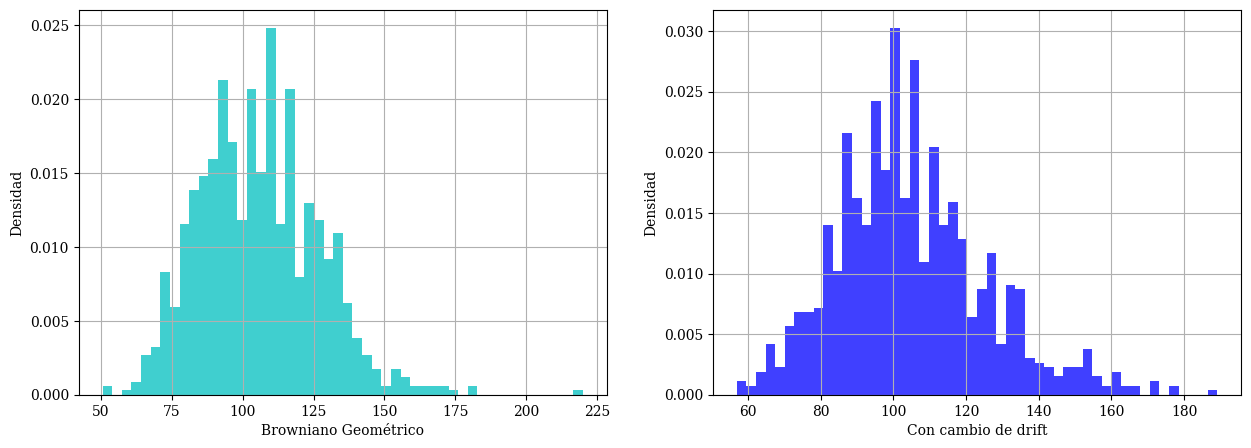

In [ ]:
plt.figure(1)

plt.subplot(121)
plt.hist(ST,50, density=True, facecolor='c', alpha=0.75) # density=True indica que se hace la gráfica de la frecuencia relativa "por unidad de longitud"
plt.xlabel('Browniano Geométrico')
plt.ylabel('Densidad')
plt.grid(True)


plt.subplot(122)
plt.hist(ST_tilde,50, density=True, facecolor='b', alpha=0.75) # density=True indica que se hace la gráfica de la frecuencia relativa "por unidad de longitud"
plt.xlabel('Con cambio de drift')
plt.ylabel('Densidad')
plt.grid(True)


plt.show()

## Comparamos los parámetros de las distribuciones

In [ ]:
(np.mean(ST)-np.mean(ST_tilde))/np.mean(ST)

np.float64(0.007818315071414825)

In [ ]:
np.std(ST)

np.float64(20.89226601511784)

In [ ]:
np.std(ST_tilde)

np.float64(20.600162866147482)